In [1]:
# If we are on colab: this clones the repo and installs the dependencies
from pathlib import Path
from omegaconf import OmegaConf
from gluefactory.datasets import get_dataset
from gluefactory.utils.tensor import batch_to_device
import torch

torch.set_grad_enabled(True)
images = Path("assets")


from gluefactory.models import get_model
from gluefactory.settings import root
from matplotlib import pyplot as plt
import numpy as np

In [2]:
conf = OmegaConf.load("../gluefactory/configs/superpoint+simpleglue_megadepth_debug.yaml")

In [3]:
device= 'cpu'

In [4]:
data_conf = (conf.data)
dataset = get_dataset(data_conf.name)(data_conf)

[09/13/2025 21:36:00 gluefactory.datasets.base_dataset INFO] Creating dataset MegaDepth


In [5]:
train_loader = dataset.get_data_loader("train", distributed=False)


[09/13/2025 21:36:00 gluefactory.datasets.megadepth INFO] Sampling new train data with seed 0.


In [6]:
state_dict = torch.load(
    str(root / 'ckpt/sp+sg_homography_initlg_onecyclelr_correctdata/checkpoint_38_45000.tar'), map_location="cpu", weights_only=False
)

In [7]:
print(state_dict.keys())

dict_keys(['model', 'optimizer', 'lr_scheduler', 'conf', 'epoch', 'losses', 'eval'])


In [8]:
print(state_dict['eval'])

{'match_recall': 0.6709445514678956, 'match_precision': 0.9640741615295411, 'accuracy': 0.9060371971130371, 'average_precision': 0.6656433563232422, 'loss/total': 1947545.2373125, 'loss/last_rp': 1947545.2373125, 'loss/last_logvar': 0.0}


In [9]:
model = get_model(conf.model.name)(conf.model).to(device)
model.load_state_dict(state_dict["model"], strict=False)

<All keys matched successfully>

In [10]:
# train the model
torch.autograd.set_detect_anomaly(False)
tot_steps = 1
log_interval = 10
lr = 1e-5
params = [(n, p) for n, p in model.named_parameters() if p.requires_grad]
all_params = [p for n, p in params]
optimizer = torch.optim.Adam(all_params, lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, 
        lr, tot_steps, pct_start=0.01, cycle_momentum=False, anneal_strategy='linear')

step = 0
data = next(iter(train_loader))
data = batch_to_device(data, device, non_blocking=True)
data.update({'tr_logvar': False})
start_tr_logvar = tot_steps // 20
while(step < tot_steps):
    # for _, data in enumerate(train_loader):
        if step >= start_tr_logvar:
            data.update({'tr_logvar': True})
        model.train()
        optimizer.zero_grad()
        pred = model(data)
        losses, _ = model.loss(pred, data)
        loss = torch.mean(losses["total"])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(all_params, conf.train.clip_grad)
        optimizer.step()
        scheduler.step()
        if step % log_interval == 0:
            print(f"Step {step}/{tot_steps}- lr: {scheduler.get_last_lr()} - Loss total: {loss.item()}, Last rpr Loss: {losses['last_rp'].mean().item()}, Last lagvar Loss: {losses['last_logvar'].mean().item()}")
        step += 1

camera0 width height: tensor([[ 676., 1024.]])
camera1 width height: tensor([[1024.,  763.]])
Step 0/1- lr: [-1.0100929696969698e-05] - Loss total: 34.77544403076172, Last rpr Loss: 1.9707484245300293, Last lagvar Loss: 30.86141586303711


In [11]:
weighted_res_sq = (pred['p_rp_01'][..., None] * pred['gt_res0_1_sq']).sum(-2).mean(-1)
print(weighted_res_sq.max())
print(weighted_res_sq.min())
print(weighted_res_sq.mean())

tensor(400.0001, grad_fn=<MaxBackward1>)
tensor(0.0109, grad_fn=<MinBackward1>)
tensor(173.5281, grad_fn=<MeanBackward0>)


In [12]:
def plot_p_and_var(tmp_n, kps_tgt, proj, r_square, p_tgt_src, log_var, w = 640, h = 480, tp = False):
    var = torch.exp(log_var).squeeze().detach().cpu().numpy()
    kps_tgt = kps_tgt.squeeze().detach().cpu().numpy().astype(int) # target

    if tp:
        r_square = r_square.transpose(-2, -3)
        p_tgt_src = p_tgt_src.transpose(-1, -2)
    r_square_n_x = r_square.squeeze().detach()[tmp_n, :, 0].cpu().numpy()
    r_square_n_y = r_square.squeeze().detach()[tmp_n, :, 1].cpu().numpy()
    # dist = F.softmax(logits[0, 0], dim=0).detach().cpu().numpy()
    dist = p_tgt_src.squeeze()[tmp_n].detach().cpu().numpy()

    print(f'Max categorical weight {dist.max()} and weight sum {dist.sum()}')
    print(f"Min residual_sq x {r_square_n_x.min()}, Max {r_square_n_x.max()}")
    print(f"Min residual_sq y {r_square_n_y.min()}, Max {r_square_n_y.max()}")
    print(f"Weigted residual_sq sum x {(r_square_n_x * dist).sum()}")
    print(f"Weigted residual_sq sum y {(r_square_n_y * dist).sum()}")

    N = 10
    r_square_value = r_square_n_x**2 + r_square_n_y**2
    min_N = np.argsort(r_square_value)[:N]
    for i in range(N):
        print(f"Top {i} min residual_sq x: {r_square_n_x[min_N[i]]}, projected at {kps_tgt[min_N[i]]}")
        print(f"Top {i} min residual_sq y: {r_square_n_y[min_N[i]]}, projected at {kps_tgt[min_N[i]]}")

    f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.bar(kps_tgt[:, 0], dist, width=2, alpha=1)
    ax2.bar(kps_tgt[:, 1], dist, width=2, alpha=1)
    ax1.bar(kps_tgt[:, 0], r_square_n_x**0.5 / 100, width=1, color='r', alpha=0.1)
    ax2.bar(kps_tgt[:, 1], r_square_n_y**0.5 / 100, width=1, color='r', alpha=0.1)

    kp0_proj1_x = proj.squeeze()[tmp_n, 0].detach().cpu().numpy()
    kp0_proj1_y = proj.squeeze()[tmp_n, 1].detach().cpu().numpy() # point 80 projected in image 0
    variance_x = var[tmp_n, 0]
    variance_y = var[tmp_n, 1]
    from scipy.stats import norm

    print(f'Var x: {variance_x}, Var y: {variance_y}')
    w_x = np.linspace(0, w, 100)
    w_x = np.sort(np.append(w_x, kp0_proj1_x))
    w_y = norm.pdf(w_x, kp0_proj1_x, variance_x**0.5)
    h_x = np.linspace(0, h, 100)
    h_x = np.sort(np.append(h_x, kp0_proj1_y))
    h_y = norm.pdf(h_x, kp0_proj1_y, variance_y**0.5)

    # set xlim
    ax1.set_xlim([-10, w+10])
    ax2.set_xlim([-10, h+10])
    # set ylim
    ax1.set_ylim([0, 2.2])
    ax2.set_ylim([0, 2.2])
    ax1.plot(w_x, w_y, 'g--')
    ax2.plot(h_x, h_y, 'g--')

Max categorical weight 0.8226526379585266 and weight sum 1.0
Min residual_sq x 0.007166597992181778, Max 400.0
Min residual_sq y 0.009317480958998203, Max 400.0
Weigted residual_sq sum x 0.007166597992181778
Weigted residual_sq sum y 2.7099244594573975
Top 0 min residual_sq x: 0.007166597992181778, projected at [345 223]
Top 0 min residual_sq y: 0.009317480958998203, projected at [345 223]
Top 1 min residual_sq x: 0.007166597992181778, projected at [345 219]
Top 1 min residual_sq y: 15.237100601196289, projected at [345 219]
Top 2 min residual_sq x: 16.684412002563477, projected at [341 229]
Top 2 min residual_sq y: 37.16764450073242, projected at [341 229]
Top 3 min residual_sq x: 50.19234848022461, projected at [338 224]
Top 3 min residual_sq y: 1.2023717164993286, projected at [338 224]
Top 4 min residual_sq x: 0.007166597992181778, projected at [345 230]
Top 4 min residual_sq y: 50.36069869995117, projected at [345 230]
Top 5 min residual_sq x: 15.329920768737793, projected at [349

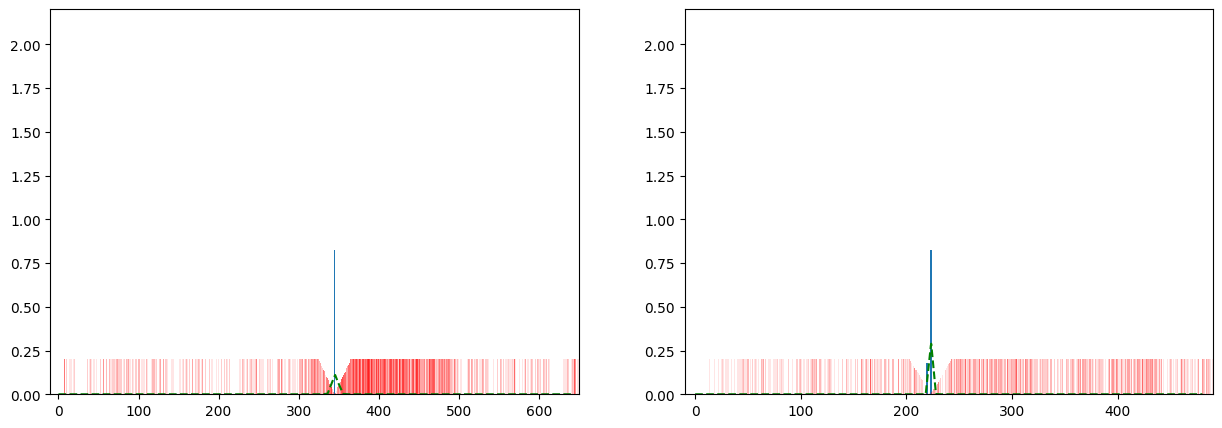

In [49]:
plot_p_and_var(900, pred['keypoints1'], pred['gt_proj_0to1'], pred['gt_res0_1_sq'], pred['p_rp_01'], pred['logvar_01'])

In [ ]:
p_idx_01_of_N = torch.argmax(pred['p_rp_01'][0][0])
res_of_N = pred['gt_res0_1_sq'][0][0][p_idx_01_of_N]
proj_of_N = pred['keypoints1'][0][p_idx_01_of_N]
prob_of_N = pred['p_rp_01'][0][0][p_idx_01_of_N]
print(res_of_N)
print(proj_of_N)
print(prob_of_N)

tensor([1000., 1000.])
tensor([162.5000, 433.5000])
tensor(0.9892, grad_fn=<SelectBackward0>)


Max categorical weight 1.0 and weight sum 1.0
Min residual_sq x 0.14563558995723724, Max 400.0
Min residual_sq y 0.2038315236568451, Max 400.0
Weigted residual_sq sum x 0.38239097595214844
Weigted residual_sq sum y 0.2038315236568451
Top 0 min residual_sq x: 0.38239097595214844, projected at [353 334]
Top 0 min residual_sq y: 0.2038315236568451, projected at [353 334]
Top 1 min residual_sq x: 21.32941246032715, projected at [357 327]
Top 1 min residual_sq y: 42.88315200805664, projected at [357 327]
Top 2 min residual_sq x: 92.51319122314453, projected at [362 325]
Top 2 min residual_sq y: 73.0772476196289, projected at [362 325]
Top 3 min residual_sq x: 0.38239097595214844, projected at [353 347]
Top 3 min residual_sq y: 180.94223022460938, projected at [353 347]
Top 4 min residual_sq x: 185.460205078125, projected at [366 335]
Top 4 min residual_sq y: 2.106785535812378, projected at [366 335]
Top 5 min residual_sq x: 206.8310546875, projected at [338 334]
Top 5 min residual_sq y: 0.2

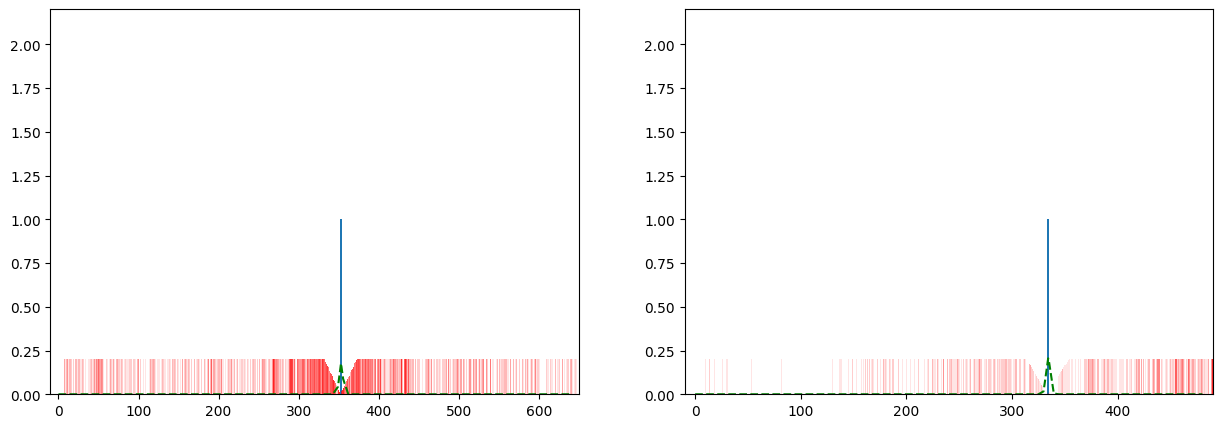

In [15]:
plot_p_and_var(1, pred['keypoints0'], pred['gt_proj_1to0'], pred['gt_res1_0_sq'], pred['p_rp_10'], pred['logvar_10'])

In [76]:
p_idx_10_of_N = torch.argmax(pred['p_rp_10'][0][0])
res_of_N = pred['gt_res1_0_sq'][0][0][p_idx_10_of_N]
proj_of_N = pred['keypoints0'][0][p_idx_10_of_N]
prob_of_N = pred['p_rp_10'][0][0][p_idx_10_of_N]
print(res_of_N)
print(proj_of_N)
print(prob_of_N)

tensor([2.1291e+00, 7.8172e+03])
tensor([326.5000,  51.5000])
tensor(1.0000, grad_fn=<SelectBackward0>)


In [78]:

def plot_var_stats(var):
    print(f'Max and Min and Median var_01 x: {var[:, 0].max()}, {var[:, 0].min()}, {var[:, 0].median()}')
    print(f'Max and Min and Median var_01 y: {var[:, 1].max()}, {var[:, 1].min()}, {var[:, 1].median()}')
    var= var.numpy()
    f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.hist(var[:, 0], bins=100)
    ax2.hist(var[:, 1], bins=100)

In [79]:
pred['logvar_10'].squeeze()[:,:1].min(0)

torch.return_types.min(
values=tensor([-3.5870], grad_fn=<MinBackward0>),
indices=tensor([362]))

In [80]:
pred['logvar_10'].mean()

tensor(2.4215, grad_fn=<MeanBackward0>)

Max and Min and Median var_01 x: 7366.34814453125, 0.0155978137627244, 3.7447805404663086
Max and Min and Median var_01 y: 13202.9609375, 0.0261829886585474, 5.099606037139893


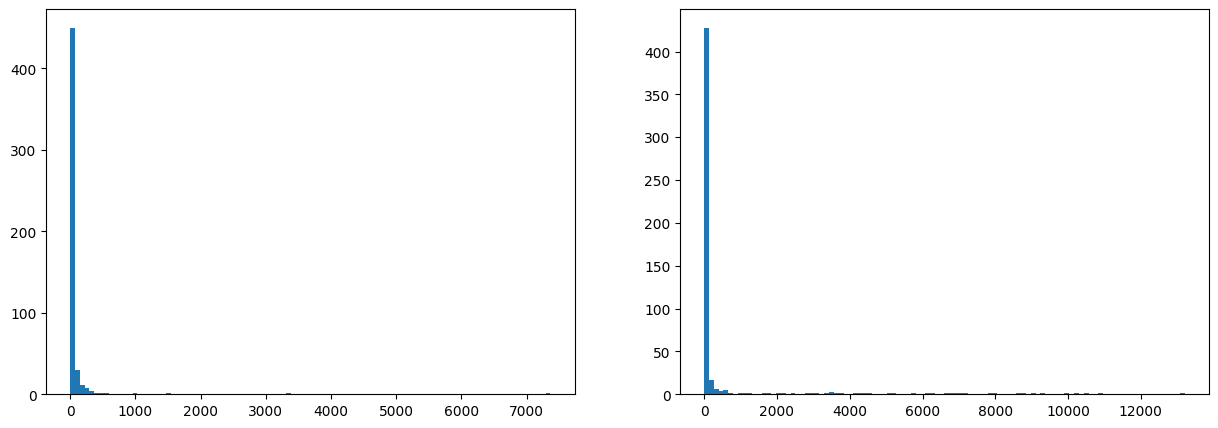

In [81]:
var_01 = torch.exp(pred['logvar_01']).squeeze().detach().cpu()
plot_var_stats(var_01)

Max and Min and Median var_01 x: 36560.31640625, 0.027680546045303345, 10.20751953125
Max and Min and Median var_01 y: 18164.046875, 0.024894697591662407, 5.600689888000488


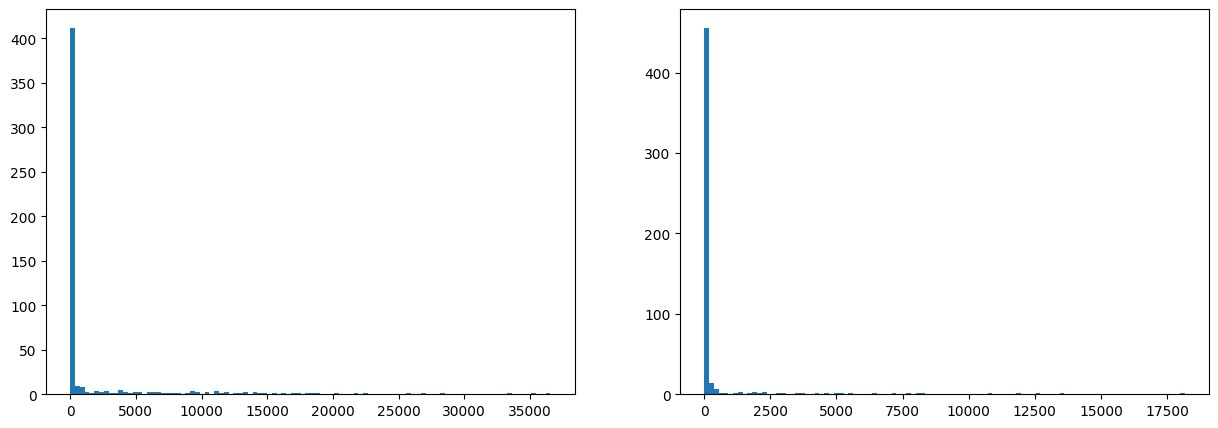

In [82]:
var_10 = torch.exp(pred['logvar_10']).squeeze().detach().cpu()
plot_var_stats(var_10)

In [21]:
import cv2

def draw_keypoints_cv(image, kps, color = (0, 255, 0), select_kp = None):
  if image.shape[1] == 3:  # RGB
    scale = image.new_tensor([0.299, 0.587, 0.114]).view(1, 3, 1, 1)
    image = (image * scale).sum(1, keepdim=True)
  image = image.squeeze().detach().cpu().numpy()
  image = (image * 255).astype(np.uint8)
  kps = kps.squeeze().detach().cpu().numpy()
    
  cv_kps= [cv2.KeyPoint(kp[0], kp[1], 1) for kp in kps]
  out_img = cv2.drawKeypoints(image, cv_kps, None, color=color, flags=0)

  if select_kp is not None:
    for kp in select_kp:
      cv2.circle(out_img, (int(kps[kp][0]), int(kps[kp][1])), 5, (255, 0, 0), -1)

  return out_img

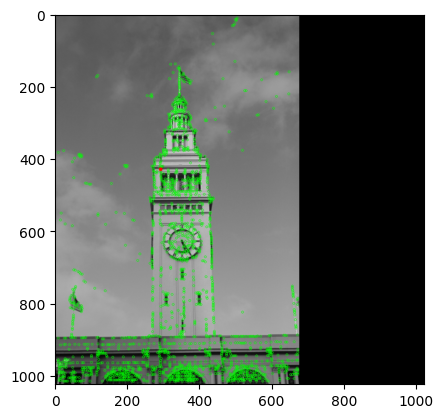

In [35]:
img0 = draw_keypoints_cv(data['view0']['image'], pred['keypoints0'], color=(0,255,0), select_kp=[900])
plt.imshow(img0)
plt.show()

In [14]:
data['view0']['image'].shape

torch.Size([1, 3, 1024, 1024])

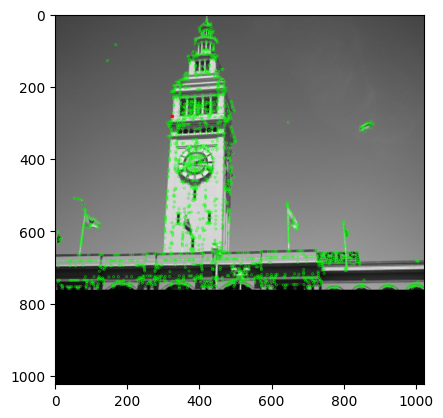

In [25]:
img1 = draw_keypoints_cv(data['view1']['image'], pred['keypoints1'], color=(0,255,0), select_kp=[0])
plt.imshow(img1)
plt.show()

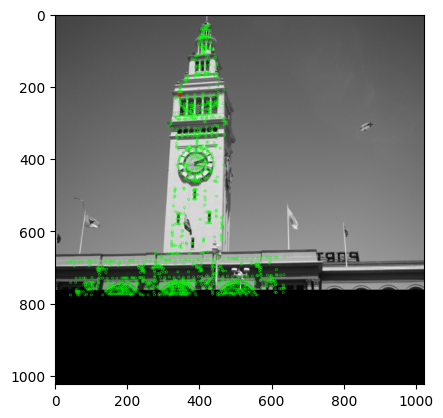

In [36]:
img1_0 = draw_keypoints_cv(data['view1']['image'], pred['gt_proj_0to1'], color=(0,255,0), select_kp=[900])
plt.imshow(img1_0)
plt.show()

In [47]:
def draw_stats(data, topn=3):
    # arg: data Nx2
    print(f'Max and Min and Median x: {data[:, 0].max()}, {data[:, 0].min()}, {data[:, 0].median()}')
    print(f'Max and Min and Median y: {data[:, 1].max()}, {data[:, 1].min()}, {data[:, 1].median()}')
    data= data.numpy()
    f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    sorted_x = np.sort(data[:, 0])
    sorted_y = np.sort(data[:, 1])
    print(f'Top {topn} min x: {sorted_x[:topn]}')
    print(f'Top {topn} min y: {sorted_y[:topn]}')
    # draw x, y value as bar chart
    ax1.bar(np.arange(len(data))[:topn], sorted_x[:topn])
    ax1.set_title('X values')
    ax2.bar(np.arange(len(data))[:topn], sorted_y[:topn])
    ax2.set_title('Y values')

In [34]:
res0_1_sq = pred["gt_res0_1_sq"][0]
res1_0_sq = pred["gt_res1_0_sq"][0]

dist0_min = torch.sum(res0_1_sq, -1).min(-1).values
best_idx0 = torch.argmin(dist0_min)
worst_idx0 = torch.argmax(dist0_min)
print(f"best_idx0 {best_idx0}, worst_idx0 {worst_idx0}")
dist1_min = torch.sum(res1_0_sq, -1).min(-1).values
best_idx1 = torch.argmin(dist1_min)
worst_idx1 = torch.argmax(dist1_min)
print(f"best_idx1 {best_idx1}, worst_idx1 {worst_idx1}")


best_idx0 900, worst_idx0 5
best_idx1 156, worst_idx1 0


Max and Min and Median x: 400.0, 0.007166597992181778, 400.0
Max and Min and Median y: 400.0, 0.009317480958998203, 400.0
Top 3 min x: [0.0071666 0.0071666 0.0071666]
Top 3 min y: [0.00931748 0.00931748 0.00931748]
Max and Min and Median x: 400.0, 0.0001167096197605133, 400.0
Max and Min and Median y: 400.0, 0.00043064355850219727, 400.0
Top 3 min x: [0.00011671 0.00011671 0.00011671]
Top 3 min y: [4.3064356e-04 4.3064356e-04 9.5892674e-01]


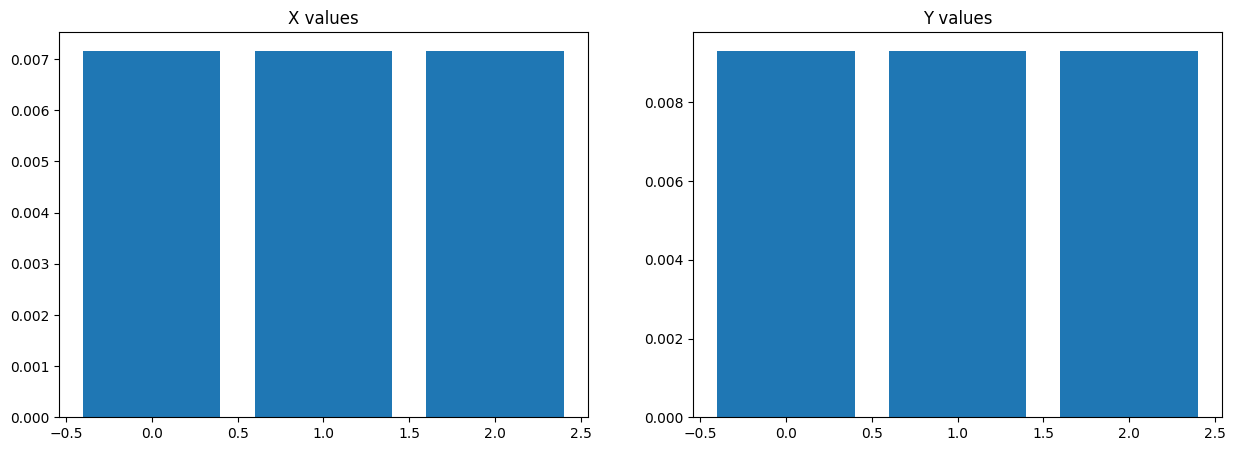

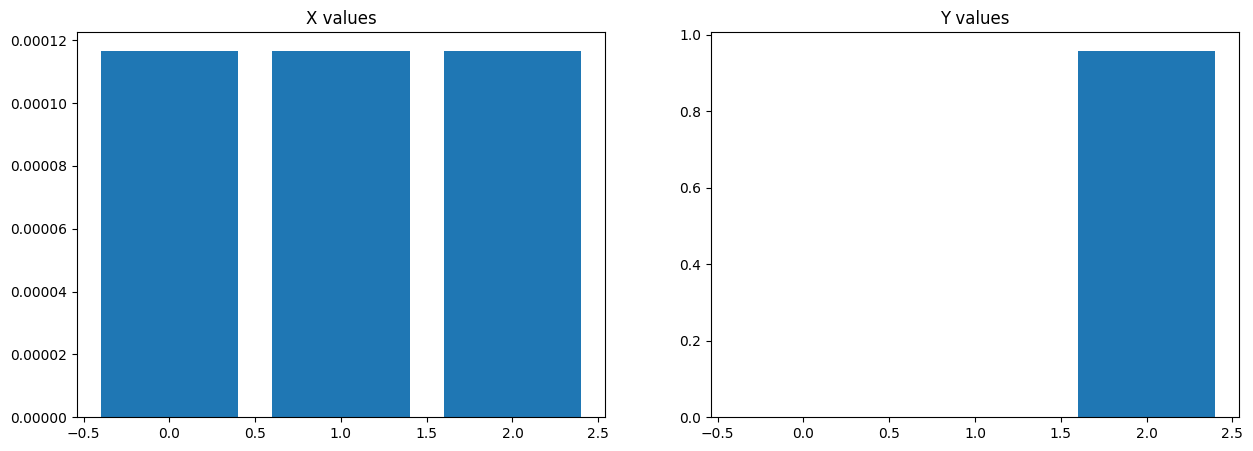

In [48]:
draw_stats(res0_1_sq[best_idx0, ...])
draw_stats(res1_0_sq[best_idx1, ...])

Max and Min and Median x: 223896.59375, 0.03137832507491112, 28283.55078125
Max and Min and Median y: 323773.71875, 11666.4130859375, 91210.75
Max and Min and Median x: 272270.0, 0.63199782371521, 67493.4296875
Max and Min and Median y: 346022.90625, 15684.3349609375, 133398.15625


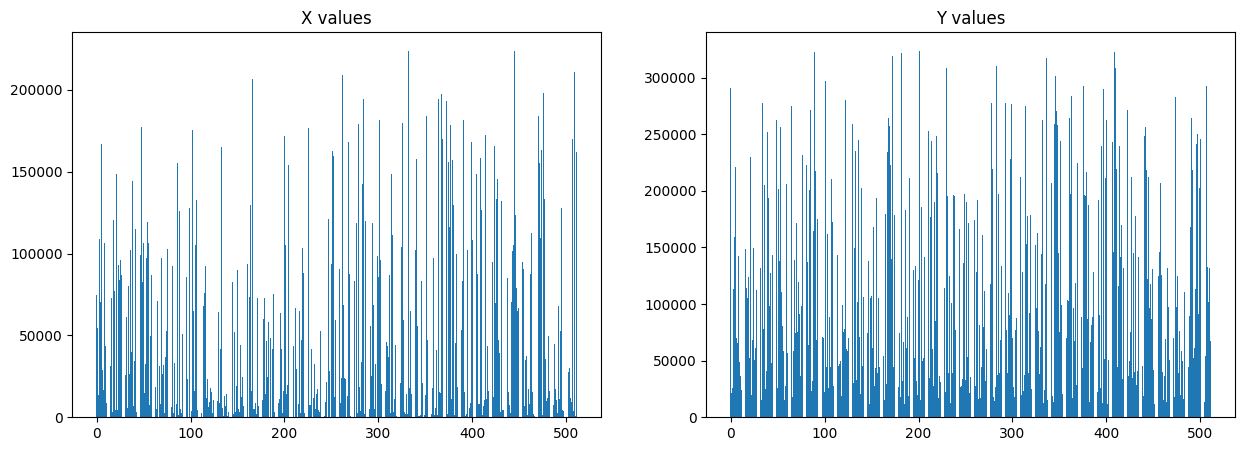

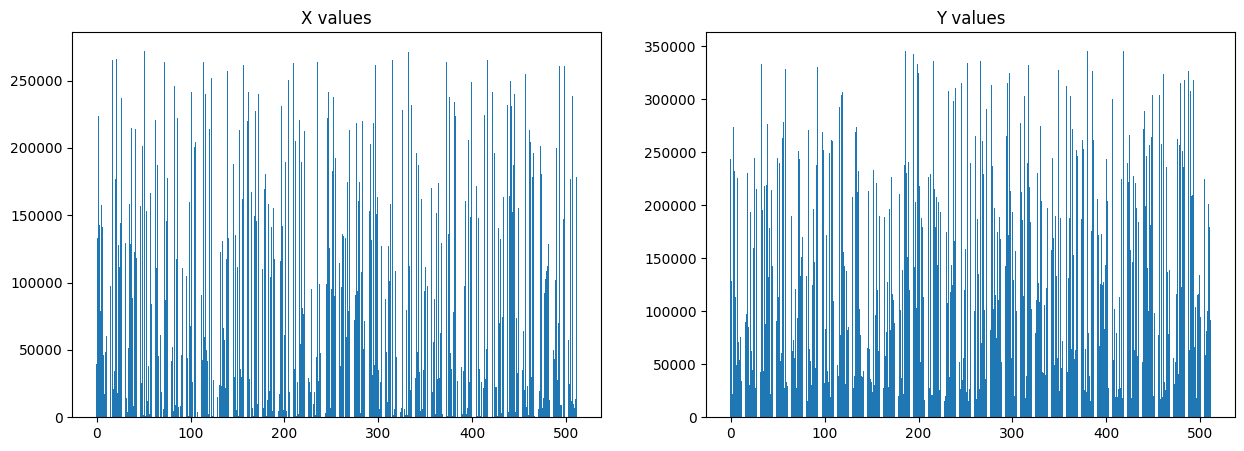

In [92]:
draw_stats(res0_1_sq[worst_idx0, ...])
draw_stats(res1_0_sq[worst_idx1, ...])

In [19]:
def draw_vertical_lines(N, size=1024, line_color=(0, 0, 0), line_thickness=1):
    """
    Create a 1024x1024 white image with vertical lines every N pixels.

    Args:
        N (int): Spacing between vertical lines (in pixels).
        size (int): Size of the image (square, default 1024).
        line_color (tuple): BGR color of the line (default black).
        line_thickness (int): Line thickness in pixels.
    """
    # Create a white image
    img = np.ones((size, size, 3), dtype=np.uint8) * 255

    # Draw vertical lines
    for x in range(0, size, N):
        cv2.line(img, (x, 0), (x, size - 1), line_color, line_thickness)

    return img

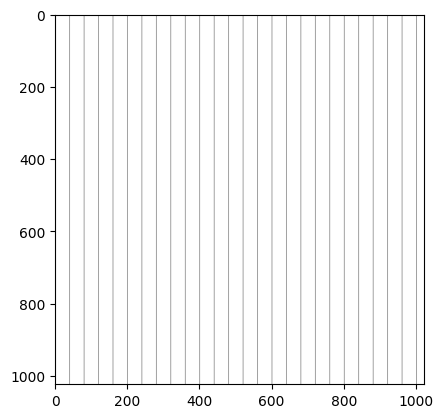

In [24]:
plt.imshow(draw_vertical_lines(40))